In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_selection import mutual_info_classif

In [2]:
fresado_h1 = pd.read_csv('data/fresado_H1_norm.csv')
fresado_h2 = pd.read_csv('data/fresado_H2_norm.csv')
fresado_h3 = pd.read_csv('data/fresado_H3_norm.csv')

In [3]:
H = pd.concat([fresado_h1, fresado_h2, fresado_h3], axis=0)

In [4]:
# Pasamos la variable categórica 'Herramienta' a una variable numérica.
H.Herramienta.replace({'Nueva':3, 'Usada':2, 'Muy Usada':1}, inplace=True)

In [5]:
X = H.copy()
X.drop(['CH', 'Mecanizado', 'Tiempo'], axis=1, inplace=True)
y = X.pop('Herramienta')
cols = ['RMS','AMP','ENER','P_FRQ','PCNTS','C_FRQ', 'I_FRQ','A_FRQ',
        'R_FRQ','DURATION','ASL','COUN','ABS_ENERGY', 'SIG_STRNGTH','RISE']

In [6]:
def make_mi_scores(X, y, cols):
    mi_scores = mutual_info_classif(X, y)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, cols)
mi_scores[::3] 

AMP      0.657499
I_FRQ    0.500425
P_FRQ    0.416317
RISE     0.235680
PCNTS    0.202435
Name: MI Scores, dtype: float64

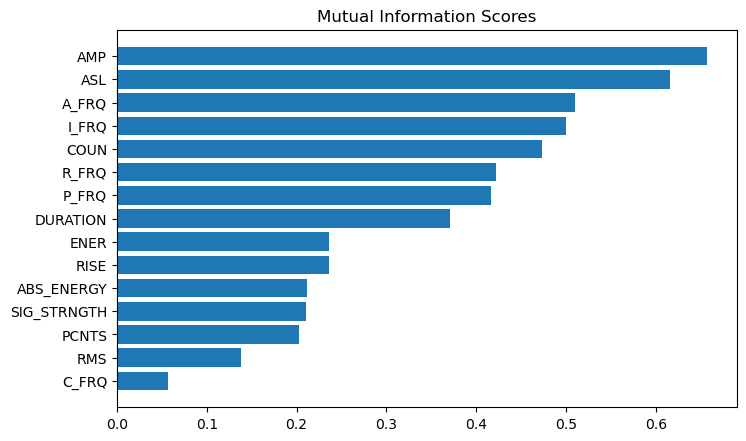

In [7]:
def plot_utility_scores(scores):
    y = scores.sort_values(ascending=True)
    width = np.arange(len(y))
    ticks = list(y.index)
    plt.barh(width, y)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_utility_scores(mi_scores)

<AxesSubplot:xlabel='Herramienta', ylabel='ENER'>

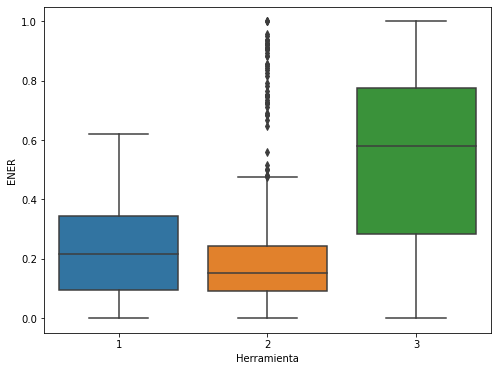

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(data=H, x=H.Herramienta, y='ENER')

<AxesSubplot:xlabel='Herramienta', ylabel='A_FRQ'>

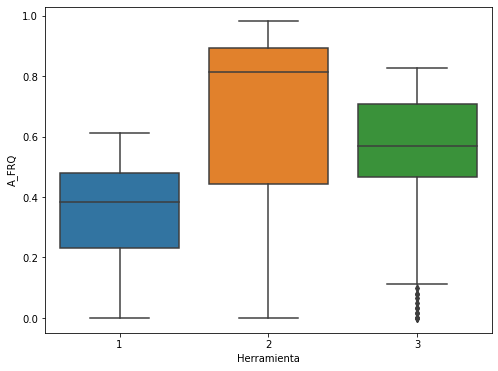

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(data=H, x=H.Herramienta, y='A_FRQ')

<AxesSubplot:xlabel='Herramienta', ylabel='COUN'>

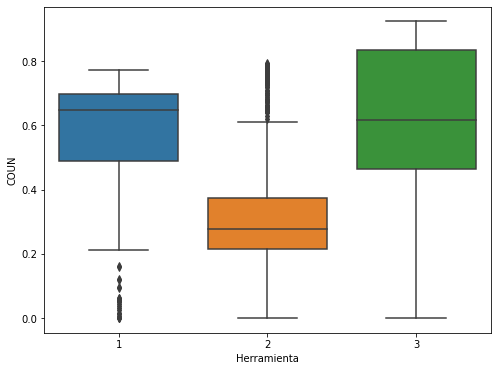

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(data=H, x=H.Herramienta, y='COUN')